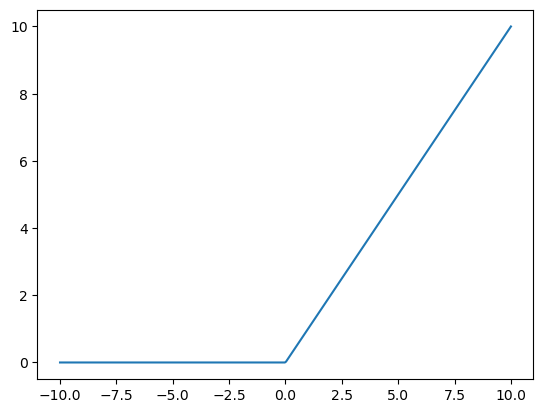

In [ ]:
# sigmoid => 이진분류 0~1 사이에
# ReLU => 0보다 큰 숫자로

import matplotlib.pyplot as plt
import numpy as np

def relu(x):
    # 0과 x를 비교해서 큰값을 반환
    return np.maximum(0, x)

# -10 ~ 10 사이의 숫자 400개 순차적으로 생성
x = np.linspace(-10, 10, 400)
y = relu(x)
plt.plot(x, y)
plt.show()

In [5]:
import numpy as np

x = np.array([[1, 1], [1, 0], [0, 1], [0, 0]])
y = np.array([[0], [1], [1], [0]])

# (n, 2) => (n, 1) => sigmoid (마지막에 결과가 0 또는 1이므로 이진분류)
x.shape, y.shape

((4, 2), (4, 1))

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(2, )),    # 특성의 갯수 2
    Dense(units=16, activation="relu"),
    Dense(units=1, activation="sigmoid")
])

model.summary()

# Param calculation 
# INPUT(2) * DENSE(16) + BIAS(16) = 48
# DENSE(16) + BIAS(1) = 17


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy']) 

In [14]:
model.fit(x, y, epochs=1000, verbose=2)

Epoch 1/1000
1/1 - 0s - 31ms/step - accuracy: 1.0000 - loss: 0.0146
Epoch 2/1000
1/1 - 0s - 33ms/step - accuracy: 1.0000 - loss: 0.0145
Epoch 3/1000
1/1 - 0s - 34ms/step - accuracy: 1.0000 - loss: 0.0145
Epoch 4/1000
1/1 - 0s - 37ms/step - accuracy: 1.0000 - loss: 0.0145
Epoch 5/1000
1/1 - 0s - 31ms/step - accuracy: 1.0000 - loss: 0.0145
Epoch 6/1000
1/1 - 0s - 32ms/step - accuracy: 1.0000 - loss: 0.0145
Epoch 7/1000
1/1 - 0s - 33ms/step - accuracy: 1.0000 - loss: 0.0145
Epoch 8/1000
1/1 - 0s - 33ms/step - accuracy: 1.0000 - loss: 0.0145
Epoch 9/1000
1/1 - 0s - 34ms/step - accuracy: 1.0000 - loss: 0.0145
Epoch 10/1000
1/1 - 0s - 34ms/step - accuracy: 1.0000 - loss: 0.0144
Epoch 11/1000
1/1 - 0s - 33ms/step - accuracy: 1.0000 - loss: 0.0144
Epoch 12/1000
1/1 - 0s - 31ms/step - accuracy: 1.0000 - loss: 0.0144
Epoch 13/1000
1/1 - 0s - 32ms/step - accuracy: 1.0000 - loss: 0.0144
Epoch 14/1000
1/1 - 0s - 34ms/step - accuracy: 1.0000 - loss: 0.0144
Epoch 15/1000
1/1 - 0s - 34ms/step - accura

In [15]:
pred = model.predict(x)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


array([[0.00493108],
       [0.99507827],
       [0.99479485],
       [0.00545823]], dtype=float32)

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input

inputs = Input(shape=(2,))
hidden = Dense(units=16, activation="relu")(inputs)
outputs = Dense(units=1, activation="sigmoid")(hidden)

hidden_model = Model(inputs, hidden)
hidden_model.summary()

hidden_output = hidden_model.predict(x)
print(hidden_output.shape)
print(hidden_output)
# model = Model(inputs, outputs)
# model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │            48 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48 (192.00 B)

 Trainable params: 48 (192.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
(4, 16)
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.4987266  0.         0.         0.32285374
  0.5904425  0.         0.23893386 0.64491916]
 [0.         0.14866889 0.         0.         0.50364554 0.
  0.         0.         0.21319735 0.1309638  0.         0.14001107
  0.47179103 0.         0.3846869  0.35560888]
 [0.12592924 0.         0.02729493 0.         0.         0.
  0.         0.         0.28552926 0.         0.         0.18284267
  0.11865145 0.         0.         0.28931028]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]]


---

In [22]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/Advertising.csv")
df

,ID,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [52]:
x = df[['TV', 'Radio', 'Newspaper']].values
y = df['Sales'].values
x.shape, y.shape

((200, 3), (200,))

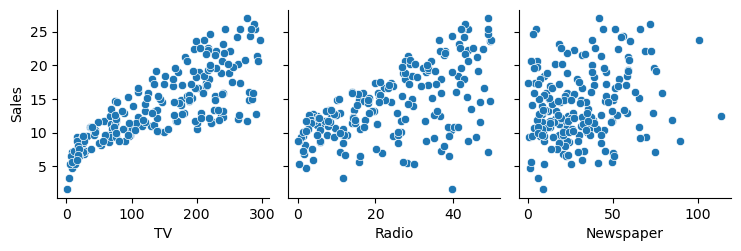

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(data=df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars=['Sales'])
plt.show()

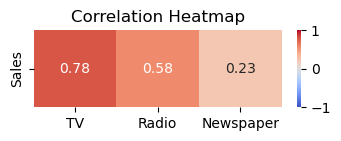

In [ ]:
x_vars = ['TV', 'Radio', 'Newspaper']
y_vars = ['Sales']
corr = df[x_vars + y_vars].corr().loc[y_vars, x_vars]
plt.figure(figsize=(4, 1))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [139]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((160, 3), (40, 3), (160,), (40,))

In [151]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_train_scaled.shape, x_test_scaled.shape

((160, 3), (40, 3))

In [152]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(3,)),
    Dense(units=12, activation="relu"),
    Dense(units=1, activation="linear") # 회귀니까 계산한 값 그대로 출력
])

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 12)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

In [153]:
from tensorflow.keras.optimizers import Adam

# adam 기본 learning_rate 값 0.001
optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss="mse", # mse 오차제곱 평균 => 큰오차를 강하게 줄임
    metrics=['mae'] # mae 오차절대값 평균 => 평가지표로 사용
) 

In [167]:
history = model.fit(
    x_train_scaled, 
    y_train, 
    epochs=600, 
    validation_data=(x_test_scaled, y_test),    
    verbose=2
)

Epoch 1/600
5/5 - 0s - 20ms/step - loss: 0.1298 - mae: 0.2691 - val_loss: 1.1867 - val_mae: 0.5671
Epoch 2/600
5/5 - 0s - 16ms/step - loss: 0.1300 - mae: 0.2690 - val_loss: 1.1883 - val_mae: 0.5665
Epoch 3/600
5/5 - 0s - 16ms/step - loss: 0.1299 - mae: 0.2684 - val_loss: 1.1900 - val_mae: 0.5664
Epoch 4/600
5/5 - 0s - 16ms/step - loss: 0.1298 - mae: 0.2683 - val_loss: 1.1880 - val_mae: 0.5655
Epoch 5/600
5/5 - 0s - 23ms/step - loss: 0.1295 - mae: 0.2686 - val_loss: 1.1850 - val_mae: 0.5664
Epoch 6/600
5/5 - 0s - 15ms/step - loss: 0.1296 - mae: 0.2692 - val_loss: 1.1843 - val_mae: 0.5670
Epoch 7/600
5/5 - 0s - 20ms/step - loss: 0.1297 - mae: 0.2694 - val_loss: 1.1841 - val_mae: 0.5669
Epoch 8/600
5/5 - 0s - 19ms/step - loss: 0.1305 - mae: 0.2703 - val_loss: 1.1786 - val_mae: 0.5666
Epoch 9/600
5/5 - 0s - 17ms/step - loss: 0.1297 - mae: 0.2696 - val_loss: 1.1853 - val_mae: 0.5664
Epoch 10/600
5/5 - 0s - 16ms/step - loss: 0.1300 - mae: 0.2694 - val_loss: 1.1918 - val_mae: 0.5662
Epoch 11/

In [166]:
from sklearn.metrics import r2_score

y_pred = model.predict(x_test_scaled)
r2_score(y_test, y_pred)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


0.9608256866811873

In [110]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

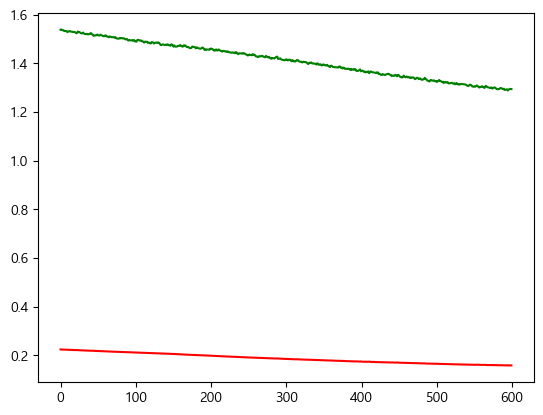

In [163]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], color="red")       # loss: for x_train_scaled
plt.plot(history.history['val_loss'], color="green") # validation loss: for y_test
plt.show()

In [171]:
y_pred = model.predict(x_test_scaled)
y_pred[:5]


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array([[22.773233],
       [21.55076 ],
       [25.529282],
       [10.564969],
       [10.643793]], dtype=float32)

In [172]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)


0.9632830047660463

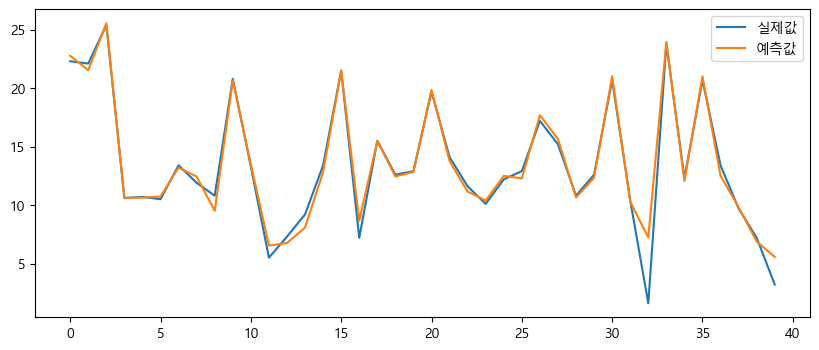

In [168]:
import matplotlib.pyplot as plt
from seaborn_cjk import patch
patch()

plt.figure(figsize=(10, 4))
plt.plot(y_test, label="실제값")
plt.plot(y_pred, label="예측값")
plt.legend()
plt.show()

In [169]:
# 스케일러 + 모델 저장
import joblib

joblib.dump(scaler, "./pkl/20260529_sales_scaler.pkl")
model.save('./pkl/20260529_sales_model.keras')

In [170]:
from tensorflow.keras.models import load_model
import joblib

scaler = joblib.load("./pkl/20260529_sales_scaler.pkl")
model = load_model('./pkl/20260529_sales_model.keras')
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 12)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185 (744.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 124 (500.00 B)